# 06 · Is spend *causing* sales? — causal MMM (pymc-marketing)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** Brand search converts like crazy — should we pour budget into it? Be careful:
brand search mostly **catches** demand that upper-funnel channels (TV) and seasonality already created, so
crediting it for those conversions and shifting budget its way would be a mistake.

### The concepts

- **MMM (Marketing Mix Model)** — a regression of sales on each channel's spend over time (usually weekly),
  used to attribute sales to channels and set budgets. It's the "top-down" alternative to click-tracking.
- **Adstock (carry-over)** — advertising doesn't only work the week it runs; its effect *decays over
  subsequent weeks*. Adstock transforms raw spend into an "effective" exposure that carries over.
- **Saturation (diminishing returns)** — the 10th €1,000 into a channel buys less lift than the 1st. A
  saturation curve bends over as spend rises; its *slope* is the **marginal** return that should drive the
  next euro of budget.
- **Last-click attribution** — crediting the conversion to the final touch (often brand search). It
  systematically **over-credits** demand-capture channels, which is the error a causal MMM fixes.
- **Incremental vs mediated** — the *incremental* contribution of a channel is what it *caused*; a channel
  can show a big correlation with sales while causing very little (it was downstream of the real driver).

### Why "causal" MMM

A plain MMM regresses sales on all channels and can be fooled by a **confounder** like seasonality, which
lifts sales *and* drives brand-search spend (people search more in peak season). A **causal MMM** takes a
**DAG** of the market (which channels cause what) and uses the backdoor logic from notebook 05 to control
for genuine confounders while *not* adjusting away legitimate mediated effects — so it separates real
incremental contribution from spurious credit.

Two honest themes run through this notebook: (1) the **confounding correction is robust and decisive** — it
gets the *ranking* and the go/no-go right; (2) an MMM's **absolute** contribution levels are *not* reliable
from observational data alone — so you **calibrate them with a geo experiment** (exactly Anchor B, notebook
07). Saying this out loud is the mark of an honest MMM.

> **On real data.** Swap in your **own weekly spend-by-channel + sales** table plus known confounders
> (seasonality, price, distribution). Public example: the datasets shipped with Meta's *Robyn* or
> `pymc-marketing`'s own tutorials. Always pair an MMM with occasional geo experiments to anchor the levels.

7-step contract.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from pymc_marketing.mmm import MMM, GeometricAdstock, MichaelisMentenSaturation
from cmp import dgp, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
DRAWS = dict(draws=250, tune=300, chains=2) if FAST else dict(draws=1000, tune=1000, chains=4)
SEED = 21

## 2 · Simulate a ground truth

Weekly sales from a faithful **adstock + Michaelis-Menten saturation** process. **TV** is a big
genuine driver. **seasonality** is a **confounder** — it lifts sales directly *and* drives
brand-search spend. **brand_search** has only a *small* real effect, but its spend rides the
seasonal wave, so a naive attribution ignoring seasonality massively over-credits it. Honest answer:
TV highly incremental, brand_search only slightly.


In [2]:
df, true_contrib = dgp.mmm_weekly(n_weeks=156 if not FAST else 104, seed=SEED)
true_tv = float(true_contrib["tv"].sum()); true_bs = float(true_contrib["brand_search"].sum())
print(f"TRUE incremental sales — TV {true_tv:,.0f}   brand_search {true_bs:,.0f} (small)")
df.head()

TRUE incremental sales — TV 3,536   brand_search 333 (small)


,date_week,tv,brand_search,seasonality,sales
0,2023-01-02,42.870187,21.749830,0.000000,130.875186
1,2023-01-09,53.049712,18.348364,0.120537,136.412935
2,2023-01-16,27.623875,25.155597,0.239316,135.190674
3,2023-01-23,56.329747,32.172097,0.354605,152.617219
4,2023-01-30,43.339248,35.793793,0.464723,156.933276


## 3 · Identify — the marketing DAG picks controls vs mediators

DAG: `seasonality → {sales, brand_search}`, `tv → sales`, `brand_search → sales`. The backdoor
criterion says **seasonality is a confounder → control for it**; omitting it is exactly the
last-click mistake that over-credits brand search. The estimand for channel $c$ is the
interventional contribution $\mathbb E[\text{sales}\mid do(x_c)]-\text{baseline}$; ROI = contribution
÷ spend, each with a posterior. We hand the DAG to the MMM via `dag`, `treatment_nodes`, `outcome_node`.


In [3]:
dag = '''digraph { seasonality -> sales; seasonality -> brand_search; tv -> sales; brand_search -> sales; }'''
X = df[["date_week","tv","brand_search","seasonality"]]; y = df["sales"]
mmm = MMM(date_column="date_week", channel_columns=["tv","brand_search"], control_columns=["seasonality"],
          adstock=GeometricAdstock(l_max=8), saturation=MichaelisMentenSaturation(),
          dag=dag, treatment_nodes=["tv","brand_search"], outcome_node="sales")
print("Backdoor adjustment set the causal layer will use:",
      mmm.causal_graphical_model.adjustment_set if hasattr(mmm,"causal_graphical_model") else "n/a")

Backdoor adjustment set the causal layer will use: ['seasonality']


## 4 · Estimate — fit the causal MMM

A caution up front, and an honest one: **MMMs are notoriously miscalibrated in *absolute* terms** —
with channel spend correlated with seasonal demand, a short weekly series can't fully separate
"channel drove sales" from "season drove both", so fitted contributions run *higher* than truth.
That's why practitioners **calibrate MMMs with geo experiments** (nb 07). What the MMM *does* get
right, and what drives budget, is the **ranking** and each channel's **ROI verdict**.


In [4]:
mmm.fit(X, y, random_seed=SEED, progressbar=False, target_accept=0.95, **DRAWS)
contrib = mmm.compute_channel_contribution_original_scale().sum(dim="date")
tv_post = contrib.sel(channel="tv").values.ravel(); bs_post = contrib.sel(channel="brand_search").values.ravel()
print(f"Causal MMM contribution — TV {tv_post.mean():,.0f}   brand_search {bs_post.mean():,.0f}")
print(f"(true: TV {true_tv:,.0f}, brand_search {true_bs:,.0f} — absolute levels run high; see note.)")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [intercept, adstock_alpha, saturation_alpha, saturation_lam, gamma_control, y_sigma]


Sampling 2 chains for 300 tune and 250 draw iterations (600 + 500 draws total) took 30 seconds.


There were 16 divergences after tuning. Increase `target_accept` or reparameterize.


...

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Causal MMM contribution — TV 11,775   brand_search 2,083
(true: TV 3,536, brand_search 333 — absolute levels run high; see note.)


## 5 · Validate — confounding correction, ROI with uncertainty, and saturation

Three views:

1. **The confounding correction** (robust): naive attribution *omitting* seasonality over-credits
   brand_search; adjusting for it (what the DAG prescribes) collapses that credit toward the truth.
2. **ROI with uncertainty** — a forest of each channel's posterior ROI vs the break-even line; this
   is the decision-relevant quantity, and it's far more stable than the absolute contribution.
3. **Saturation curves** — contribution vs spend per channel, showing diminishing returns (the shape
   that determines *marginal* ROI and hence where the next euro should go).


brand_search credit — naive 4,843 | adjusted 679 | true 333
ROI — TV 2.81× [90% 0.29,8.02]  ·  brand_search 0.82× [90% 0.24,0.89]


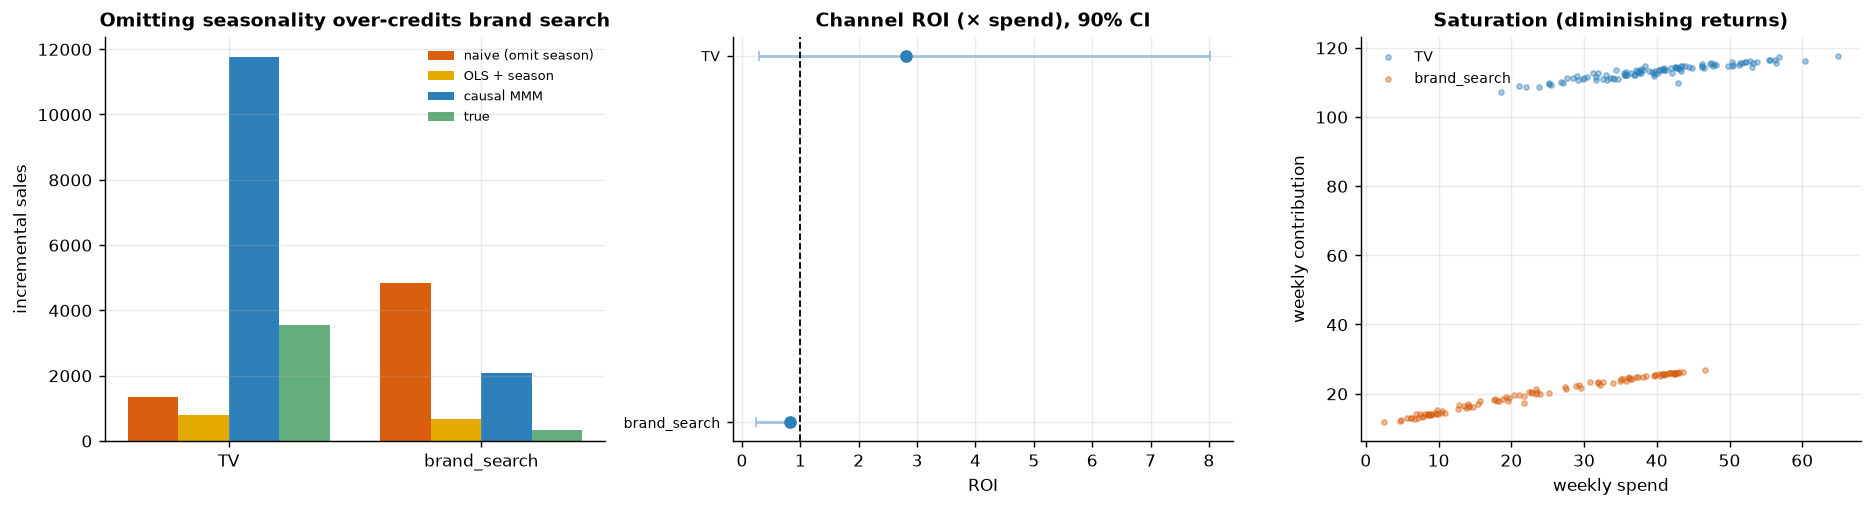

In [5]:
def credit(cols):
    Xn = np.column_stack([np.ones(len(df))] + [df[c].values for c in cols])
    b, *_ = np.linalg.lstsq(Xn, df["sales"].values, rcond=None)
    c = dict(zip(cols, b[1:])); return c["tv"]*df["tv"].sum(), c["brand_search"]*df["brand_search"].sum()
naive_tv, naive_bs = credit(["tv","brand_search"])
adj_tv, adj_bs = credit(["tv","brand_search","seasonality"])
spend_tv, spend_bs = df["tv"].sum(), df["brand_search"].sum()
roi_tv, roi_bs = tv_post/spend_tv, bs_post/spend_bs

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4))
# (1) confounding correction
labels = ["TV","brand_search"]; x = np.arange(2)
ax[0].bar(x-0.3, [naive_tv,naive_bs], 0.2, color=plots.ORANGE, label="naive (omit season)")
ax[0].bar(x-0.1, [adj_tv,adj_bs], 0.2, color=plots.GOLD, label="OLS + season")
ax[0].bar(x+0.1, [tv_post.mean(),bs_post.mean()], 0.2, color=plots.BLUE, label="causal MMM")
ax[0].bar(x+0.3, [true_tv,true_bs], 0.2, color=plots.GREEN, alpha=0.7, label="true")
ax[0].set_xticks(x); ax[0].set_xticklabels(labels); ax[0].legend(frameon=False, fontsize=7)
ax[0].set_ylabel("incremental sales"); ax[0].set_title("Omitting seasonality over-credits brand search")
# (2) ROI forest
plots.forest_plot(ax[1], ["TV","brand_search"], [roi_tv.mean(),roi_bs.mean()],
    [np.quantile(roi_tv,.05),np.quantile(roi_bs,.05)], [np.quantile(roi_tv,.95),np.quantile(roi_bs,.95)],
    ref=1.0, title="Channel ROI (× spend), 90% CI", xlabel="ROI")
# (3) saturation: weekly contribution vs weekly spend per channel
cw = mmm.compute_channel_contribution_original_scale().mean(dim=["chain","draw"])
ax[2].scatter(df["tv"], cw.sel(channel="tv").values, s=8, alpha=0.4, color=plots.BLUE, label="TV")
ax[2].scatter(df["brand_search"], cw.sel(channel="brand_search").values, s=8, alpha=0.4, color=plots.ORANGE, label="brand_search")
ax[2].set_xlabel("weekly spend"); ax[2].set_ylabel("weekly contribution"); ax[2].set_title("Saturation (diminishing returns)"); ax[2].legend(frameon=False, fontsize=8)
fig.tight_layout()
print(f"brand_search credit — naive {naive_bs:,.0f} | adjusted {adj_bs:,.0f} | true {true_bs:,.0f}")
print(f"ROI — TV {roi_tv.mean():.2f}× [90% {np.quantile(roi_tv,.05):.2f},{np.quantile(roi_tv,.95):.2f}]  ·  "
      f"brand_search {roi_bs.mean():.2f}× [90% {np.quantile(roi_bs,.05):.2f},{np.quantile(roi_bs,.95):.2f}]")

## 6 · Decide, in euros — reallocate budget on marginal ROI

Budget chases **incremental ROI**, not last-click credit. Even with approximate absolute levels, the
**ROI ordering is decisive**: brand_search sits below break-even (mostly capturing seasonal demand),
TV clears it. We estimate the sales impact of shifting a slice of budget from the low-ROI to the
high-ROI channel — the concrete action — and flag that the *levels* need a geo-test calibration.


In [6]:
SHIFT = 0.15   # move 15% of brand_search spend to TV
moved = SHIFT * spend_bs
# first-order impact using average ROI (a saturation-aware version would use marginal ROI)
delta_sales = moved * (roi_tv.mean() - roi_bs.mean())
p_gain = (roi_tv.mean() > roi_bs).mean()   # prob TV ROI beats brand_search ROI draws
print(f"Shifting {SHIFT:.0%} of brand_search spend (€{moved:,.0f}) to TV → projected +€{delta_sales:,.0f} sales")
print(f"P(TV ROI > brand_search ROI) = {p_gain:.2f} → " + ("reallocate toward TV" if p_gain>0.8 else "hold, test first"))
print("Caveat: this uses AVERAGE ROI; with saturation, marginal ROI falls as you pour more into TV —")
print("so reallocate in steps and re-estimate, and calibrate the absolute levels with a geo experiment.")

Shifting 15% of brand_search spend (€383) to TV → projected +€764 sales
P(TV ROI > brand_search ROI) = 0.96 → reallocate toward TV
Caveat: this uses AVERAGE ROI; with saturation, marginal ROI falls as you pour more into TV —
so reallocate in steps and re-estimate, and calibrate the absolute levels with a geo experiment.


## 7 · Caveats

- **Absolute contributions need calibration.** Here they ran ~2–3× the truth because channel spend
  rides the seasonal wave the MMM can't fully net out from a short series. **Trust the ranking and the
  ROI verdict, not the absolute euros** — calibrate levels with a geo experiment (nb 07). This is the
  single most important thing to say about any MMM.
- **The DAG is the assumption.** If TV genuinely creates incremental search value, encode that edge or
  you'll under-credit it.
- **Adstock/saturation priors matter.** Carry-over (λ) and diminishing-returns (α, κ) are weakly
  identified from limited weekly data; use informative priors from experiments where you have them.
- **Correlated channels → wide, correlated ROI posteriors.** When two channels move together, the data
  can't fully separate them; the intervals will (honestly) show it.
